In this notebook I will compute the different contributions to P3D (Lya, HCD, LyaHCD) and compare with cupix

In [1]:
import h5py
from lace.cosmo import cosmology
import numpy as np
import matplotlib.pyplot as plt
from cupix.likelihood.theory import Theory

In [2]:
with h5py.File('HCD_contribution2.hdf5', 'r') as f:
    print('Atributes:')
    print('----------------')
    for k in f.attrs.keys():
        print(f'{k} = {f.attrs[k]}')
    print('----------------')
    As = f.attrs['As']
    ns = f.attrs['ns']
    hubble = f.attrs['hubble']
    ombh2 = f.attrs['ombh2']
    omch2 = f.attrs['omch2']
    NHirange = np.linspace(f.attrs['logNHi_min'], f.attrs['logNHi_max']) 

    k_los = f['klos_Mpc'][:]
    k = f['k_Mpc'][:]
    mu = f['mu'][:]
    plin = f['plin'][:]
    p3d_hcd = f['p3d_hcd_Mpc'][:]
    p3d_lya = f['p3d_lya_Mpc'][:]
    p3d_lyahcd = f['p3d_lyahcd_Mpc'][:]

Atributes:
----------------
As = 2.105209331337507e-09
hubble = 0.6766
logNHi_max = 21.3
logNHi_min = 17.2
ns = 0.9665
ombh2 = 0.02242
omch2 = 0.11933
----------------


In [17]:
p3d_hcd_nonnan = np.nan_to_num(p3d_hcd, 0)
p3d_lya_nonnan = np.nan_to_num(p3d_lya, 0)
p3d_lyahcd_nonnan = np.nan_to_num(p3d_lyahcd, 0)

In [18]:
p3d_total = p3d_hcd_nonnan + p3d_lya_nonnan + p3d_lyahcd_nonnan

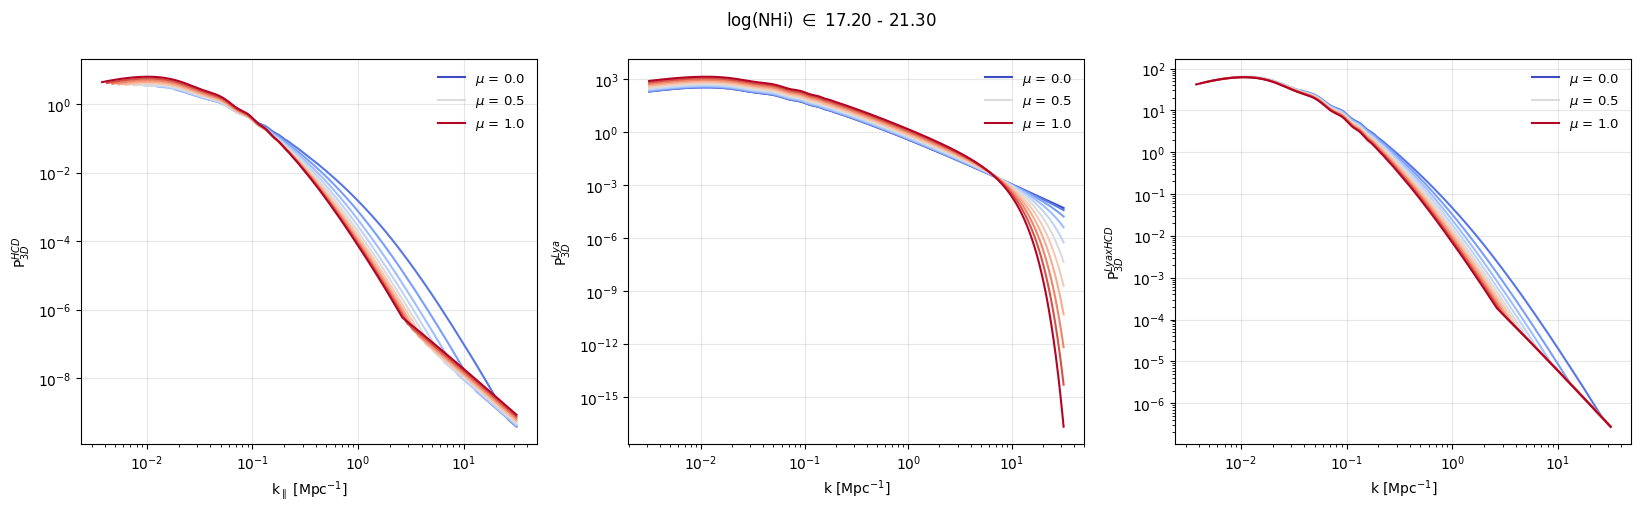

In [4]:
plt.figure(figsize=(20, 5))
plt.suptitle(r'log(NHi) $\in$ %.2f - %.2f' %(NHirange.min(), NHirange.max()))

plt.subplot(1, 3, 1)
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(mu)):
    if i in [0, 5, 10]:
        plt.plot(k, p3d_hcd[i, :], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(k, p3d_hcd[i, :])
plt.xscale('log')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{HCD}$');

plt.subplot(1, 3, 2)
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(mu)):
    if i in [0, 5, 10]:
        plt.plot(k, p3d_lya[i, :], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(k, p3d_lya[i, :])
plt.xscale('log')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{Lya}$');

plt.subplot(1, 3, 3)
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(mu)):
    if i in [0, 5, 10]:
        plt.plot(k, p3d_lyahcd[i, :], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(k, p3d_lyahcd[i, :])
plt.xscale('log')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{LyaxHCD}$');

# Cupix (linear)

In [5]:
# default cosmology for now
cosmo = cosmology.Cosmology()

In [7]:
# redshift and bias / beta from that paper
z = 2.5
bias = -0.18
beta = 1.0
# close to value used in McQuinn & White, although in there this is kpar smoothing only
kp_Mpc = 0.08 * cosmo.get_dkms_dMpc(z)
print('k_p = {:.3f} 1/Mpc'.format(kp_Mpc))
# HCD model (L_H
b_H = -0.036
beta_H = 0.5
L_H = 7.0  / cosmo.get_h()
print('L_H = {:.3f} Mpc'.format(L_H))
config = dict(bias=bias, beta=beta, q1=0, q2=0, kp_Mpc=kp_Mpc,
              include_hcd=True, b_H=b_H, beta_H=beta_H, L_H=L_H,
              verbose=True)

k_p = 5.782 1/Mpc
L_H = 10.346 Mpc


In [8]:
theory = Theory(z, fid_cosmo=cosmo, config=config)

LyaModel::setup_from_config
LyaModel::get_default_lya_params
initial values {'bias': -0.13827178966115714, 'beta': 1.4178048358716402, 'q1': 0.33369611625260176, 'kvav': 0.5709771352811059, 'av': 0.4055657283063022, 'bv': 1.6647876909430759, 'kp': 12.514370161342079, 'q2': 0.2533086488252884}
final values {'bias': -0.18, 'beta': 1.0, 'q1': 0, 'av': 0.4055657283063022, 'bv': 1.6647876909430759, 'q2': 0, 'kp_Mpc': 5.782362549994954, 'kv_Mpc': 0.25112897347553936}
ContaminantsModel::setup_from_config


I will do a version of the cupix code to try to adapt to mine

In [9]:
lya_params = theory.lya_model.get_lya_params(cosmo, params={})
hcd_params = theory.cont_model.get_hcd_params(params={})
p3d_total_cupix = []
for mu_value in mu:
    b_T, beta_T = theory._compute_lya_hcd_biases(k_los[i, :], lya_params, hcd_params)
    p3d_total_cupix.append(b_T**2 * (1 + beta_T * mu_value**2)**2 * plin)
p3d_total_cupix = np.array(p3d_total_cupix)

In [10]:
lya_params = theory.lya_model.get_lya_params(cosmo, params={})
bias = lya_params['bias']
beta = lya_params['beta']
dkms_dMpc = cosmo.get_dkms_dMpc(z)
k_d = 0.08*dkms_dMpc  # Mpc^-1
p3d_lya_cupix = []
for mu_value in mu:
    exp = np.exp(-(k_los[i, :]**2/k_d**2))
    y = bias**2 * (1 + beta * mu_value**2)**2 * plin
    p3d_lya_cupix.append(y)
p3d_lya_cupix = np.array(p3d_lya_cupix)

# Cupix (nonlinear)

I will do a version of the cupix code to try to adapt to mine

In [22]:
lya_params = theory.lya_model.get_lya_params(cosmo, params={})
hcd_params = theory.cont_model.get_hcd_params(params={})
p3d_total_cupix_nonlin = []
for mu_value in mu:
    b_T, beta_T = theory._compute_lya_hcd_biases(k_los[i, :], lya_params, hcd_params)
    nonlin = theory._compute_DNL_Arinyo(k, mu_value, plin, lya_params)
    y = b_T**2 * (1 + beta_T * mu_value**2)**2 * plin
    p3d_total_cupix_nonlin.append(y*nonlin)
p3d_total_cupix_nonlin = np.array(p3d_total_cupix_nonlin)

In [23]:
lya_params = theory.lya_model.get_lya_params(cosmo, params={})
bias = lya_params['bias']
beta = lya_params['beta']
dkms_dMpc = cosmo.get_dkms_dMpc(z)
k_d = 0.08*dkms_dMpc  # Mpc^-1
p3d_lya_cupix_nonlin = []
for mu_value in mu:
    exp = np.exp(-(k_los[i, :]**2/k_d**2))
    y = bias**2 * (1 + beta * mu_value**2)**2 * plin
    nonlin = theory._compute_DNL_Arinyo(k, mu_value, plin, lya_params)
    p3d_lya_cupix_nonlin.append(y*nonlin)
p3d_lya_cupix_nonlin = np.array(p3d_lya_cupix_nonlin)

# Comparisons

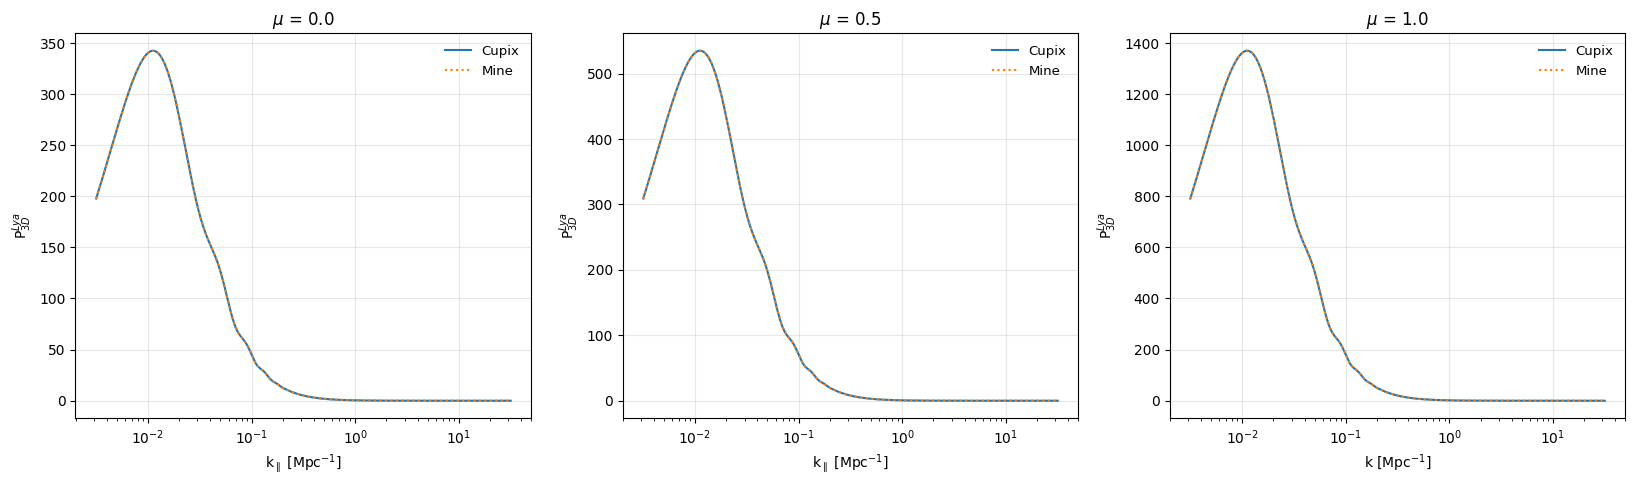

In [11]:
plt.figure(figsize=(20, 5))

plt.subplot(1, 3, 1)
i = 0
plt.plot(k, p3d_lya_cupix[i], label='Cupix')
plt.plot(k, p3d_lya[i], linestyle=':', label='Mine')
plt.xscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{Lya}$')
plt.title(r'$\mu$ = %.1f' %mu[i]);

plt.subplot(1, 3, 2)
i = 5
plt.plot(k, p3d_lya_cupix[i], label='Cupix')
plt.plot(k, p3d_lya[i], linestyle=':', label='Mine')
plt.xscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{Lya}$')
plt.title(r'$\mu$ = %.1f' %mu[i]);

plt.subplot(1, 3, 3)
i = 10
plt.plot(k, p3d_lya_cupix[i], label='Cupix')
plt.plot(k, p3d_lya[i], linestyle=':', label='Mine')
plt.xscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{Lya}$')
plt.title(r'$\mu$ = %.1f' %mu[i]);

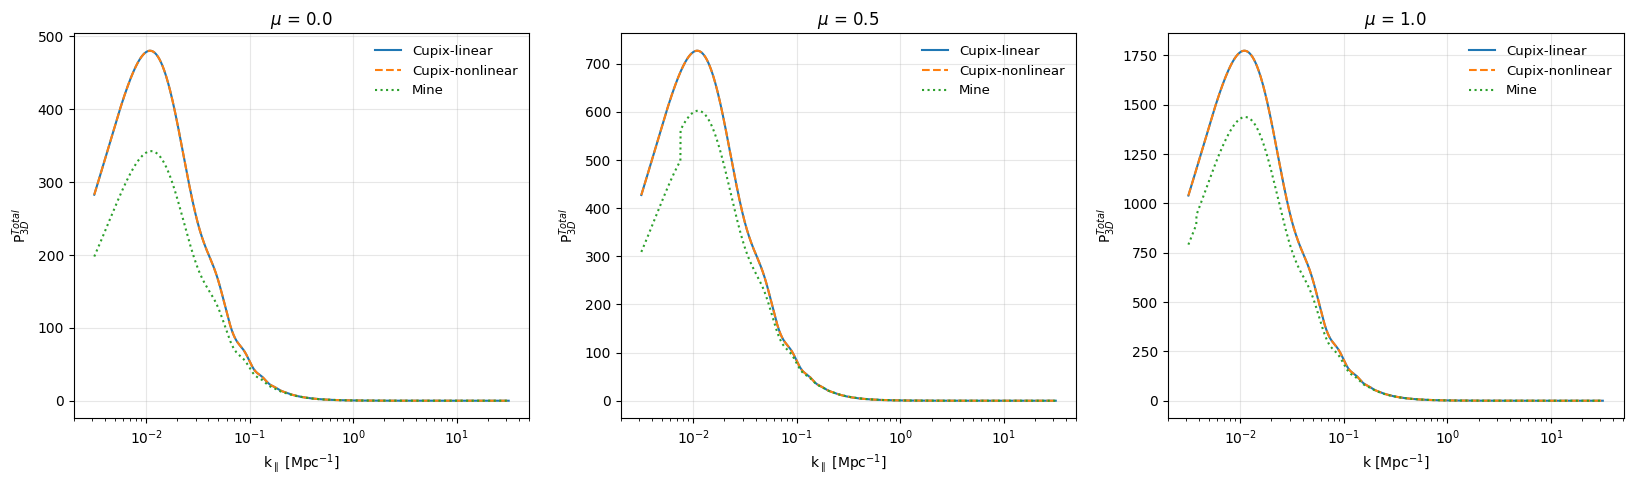

In [27]:
plt.figure(figsize=(20, 5))

plt.subplot(1, 3, 1)
i = 0
plt.plot(k, p3d_total_cupix[i], label='Cupix-linear')
plt.plot(k, p3d_total_cupix_nonlin[i], linestyle='--', label='Cupix-nonlinear')
plt.plot(k, p3d_total[i], linestyle=':', label='Mine')
plt.xscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{Total}$')
plt.title(r'$\mu$ = %.1f' %mu[i]);

plt.subplot(1, 3, 2)
i = 5
plt.plot(k, p3d_total_cupix[i], label='Cupix-linear')
plt.plot(k, p3d_total_cupix_nonlin[i], linestyle='--', label='Cupix-nonlinear')
plt.plot(k, p3d_total[i], linestyle=':', label='Mine')
plt.xscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{Total}$')
plt.title(r'$\mu$ = %.1f' %mu[i]);

plt.subplot(1, 3, 3)
i = 10
plt.plot(k, p3d_total_cupix[i], label='Cupix-linear')
plt.plot(k, p3d_total_cupix_nonlin[i], linestyle='--', label='Cupix-nonlinear')
plt.plot(k, p3d_total[i], linestyle=':', label='Mine')
plt.xscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{Total}$')
plt.title(r'$\mu$ = %.1f' %mu[i]);

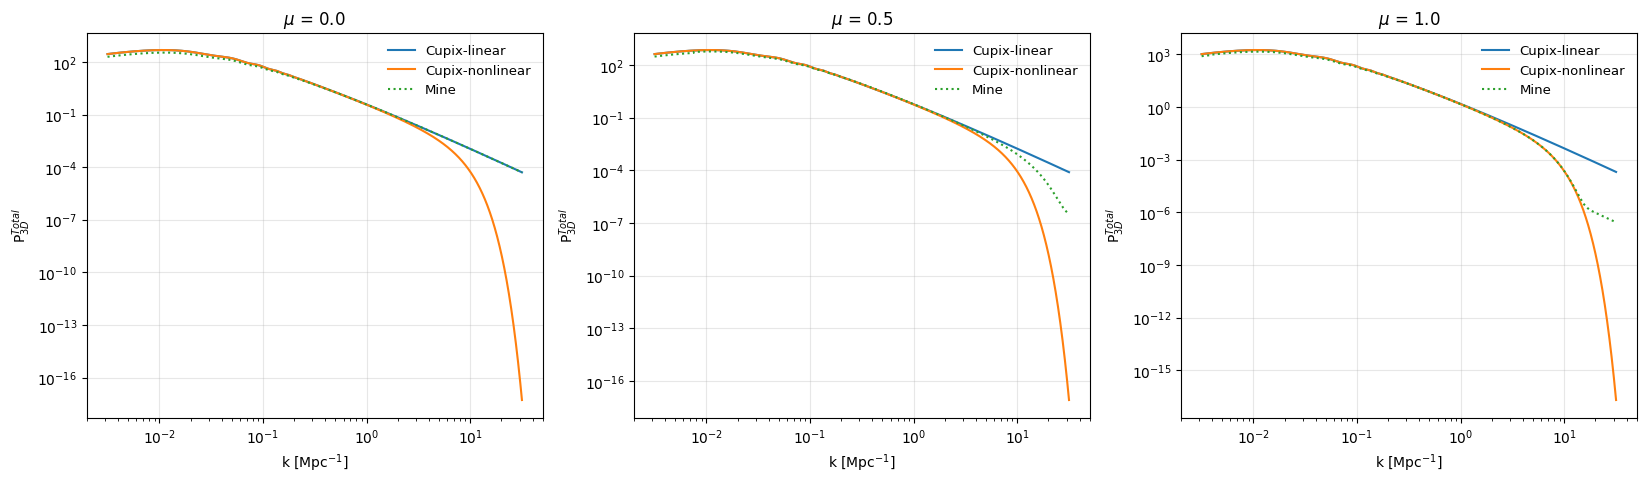

In [39]:
plt.figure(figsize=(20, 5))

plt.subplot(1, 3, 1)
i = 0
plt.plot(k, p3d_total_cupix[i], label='Cupix-linear')
plt.plot(k, p3d_total_cupix_nonlin[i], label='Cupix-nonlinear')
plt.plot(k, p3d_total[i], linestyle=':', label='Mine')
plt.xscale('log')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{Total}$')
plt.title(r'$\mu$ = %.1f' %mu[i]);

plt.subplot(1, 3, 2)
i = 5
plt.plot(k, p3d_total_cupix[i], label='Cupix-linear')
plt.plot(k, p3d_total_cupix_nonlin[i], label='Cupix-nonlinear')
plt.plot(k, p3d_total[i], linestyle=':', label='Mine')
plt.xscale('log')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{Total}$')
plt.title(r'$\mu$ = %.1f' %mu[i]);

plt.subplot(1, 3, 3)
i = 10
plt.plot(k, p3d_total_cupix[i], label='Cupix-linear')
plt.plot(k, p3d_total_cupix_nonlin[i], label='Cupix-nonlinear')
plt.plot(k, p3d_total[i], linestyle=':', label='Mine')
plt.xscale('log')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{Total}$')
plt.title(r'$\mu$ = %.1f' %mu[i]);

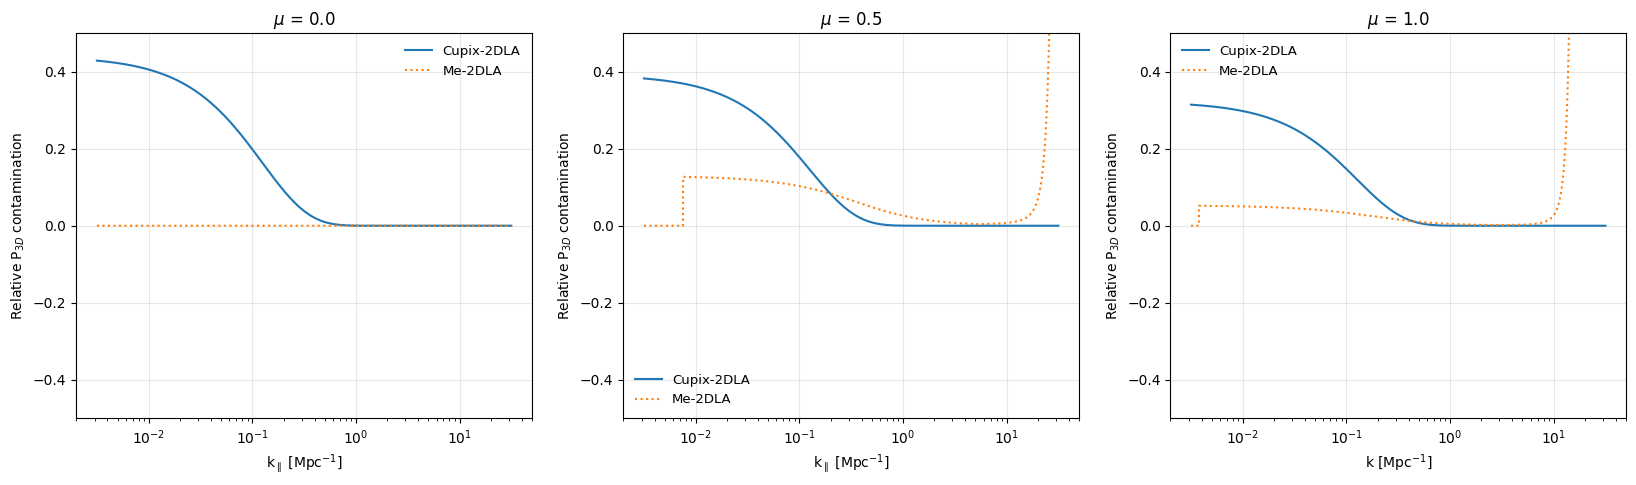

In [38]:
plt.figure(figsize=(20, 5))

plt.subplot(1, 3, 1)
i = 0
plt.plot(k, p3d_total_cupix[i]/p3d_lya_cupix[i] - 1, label='Cupix-2DLA')
plt.plot(k, p3d_total[i]/p3d_lya[i] - 1, linestyle=':', label='Me-2DLA')
plt.xscale('log')
plt.ylim(-0.5, 0.5)
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'Relative P$_{3D}$ contamination')
plt.title(r'$\mu$ = %.1f' %mu[i]);

plt.subplot(1, 3, 2)
i = 5
plt.plot(k, p3d_total_cupix[i]/p3d_lya_cupix[i] - 1, label='Cupix-2DLA')
plt.plot(k, p3d_total[i]/p3d_lya[i] - 1, linestyle=':', label='Me-2DLA')
plt.xscale('log')
plt.ylim(-0.5, 0.5)
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'Relative P$_{3D}$ contamination')
plt.title(r'$\mu$ = %.1f' %mu[i]);

plt.subplot(1, 3, 3)
i = 10
plt.plot(k, p3d_total_cupix[i]/p3d_lya_cupix[i] - 1, label='Cupix-2DLA')
plt.plot(k, p3d_total[i]/p3d_lya[i] - 1 , linestyle=':', label='Me-2DLA')
plt.xscale('log')
plt.ylim(-0.5, 0.5)
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'Relative P$_{3D}$ contamination')
plt.title(r'$\mu$ = %.1f' %mu[i]);